In [1]:
import pandas as pd

train_df = pd.read_csv("AGB_EMIT_PCA_TRAIN.csv")
test_df = pd.read_csv("AGB_EMIT_PCA_TEST.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:")
print(train_df.columns)

train_df.head()

Train shape: (3100, 318)
Test shape: (780, 314)

Columns:
Index(['dataset', 'plot_id', 'start_date', 'end_date', 'capture_start',
       'capture_end', 'EMIT_selected_date', 'EMIT_granule', 'latitude',
       'longitude',
       ...
       'EMIT_R1424', 'EMIT_R1432', 'EMIT_R1774', 'EMIT_R1781', 'EMIT_R1789',
       'EMIT_R1796', 'EMIT_PC1', 'EMIT_PC2', 'EMIT_PC3', 'EMIT_PC4'],
      dtype='object', length=318)


,dataset,plot_id,start_date,end_date,capture_start,capture_end,EMIT_selected_date,EMIT_granule,latitude,longitude,...,EMIT_R1424,EMIT_R1432,EMIT_R1774,EMIT_R1781,EMIT_R1789,EMIT_R1796,EMIT_PC1,EMIT_PC2,EMIT_PC3,EMIT_PC4
0,Belige,Big Creek_2,2021-01-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2024-07-20 20:44:04+00:00,EMIT_L2A_RFL_001_20240720T204404_2420214_006.nc,16.510577,-88.424687,...,0.362984,0.288413,0.257263,0.266405,0.274731,0.291285,17.855941,-2.906461,8.257618,-0.340598
1,Belige,Big Creek_2,2021-01-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2024-07-20 20:44:04+00:00,EMIT_L2A_RFL_001_20240720T204404_2420214_006.nc,16.510577,-88.424687,...,0.362984,0.288413,0.257263,0.266405,0.274731,0.291285,17.855941,-2.906461,8.257618,-0.340598
2,Belige,Big Creek_2,2021-01-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2024-07-20 20:44:04+00:00,EMIT_L2A_RFL_001_20240720T204404_2420214_006.nc,16.510577,-88.424687,...,0.362984,0.288413,0.257263,0.266405,0.274731,0.291285,17.855941,-2.906461,8.257618,-0.340598
3,Belige,Big Creek_2,2021-01-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2024-07-20 20:44:04+00:00,EMIT_L2A_RFL_001_20240720T204404_2420214_006.nc,16.510577,-88.424687,...,0.362984,0.288413,0.257263,0.266405,0.274731,0.291285,17.855941,-2.906461,8.257618,-0.340598
4,Belige,Big Creek_2,2021-01-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2024-07-20 20:44:04+00:00,EMIT_L2A_RFL_001_20240720T204404_2420214_006.nc,16.510577,-88.424687,...,0.362984,0.288413,0.257263,0.266405,0.274731,0.291285,17.855941,-2.906461,8.257618,-0.340598


Aggregate to Plot Level

In [2]:

print(train_df["plot_id"].value_counts().head())

# Aggregate to plot level (mean AGB)
train_plot = train_df.groupby("plot_id").mean(numeric_only=True).reset_index()
test_plot = test_df.groupby("plot_id").mean(numeric_only=True).reset_index()

print("Train plot shape:", train_plot.shape)
print("Test plot shape:", test_plot.shape)

train_plot.head()

plot_id
Channel Caye_4        120
Frenchman Caye_6      118
Frenchman Caye_3      117
Payne's Creek_2       116
Shipstern Lagoon_2    105
Name: count, dtype: int64
Train plot shape: (47, 310)
Test plot shape: (12, 306)


,plot_id,latitude,longitude,diameter,height,plant_AGB_kg,NDVI,NDRE1,NDRE2,NDRE3,...,EMIT_R1424,EMIT_R1432,EMIT_R1774,EMIT_R1781,EMIT_R1789,EMIT_R1796,EMIT_PC1,EMIT_PC2,EMIT_PC3,EMIT_PC4
0,Big Creek_2,16.510577,-88.424687,2.957143,257.628571,1.303936,0.005481,0.007623,0.006300,-0.004455,...,0.362984,0.288413,0.257263,0.266405,0.274731,0.291285,17.855941,-2.906461,8.257618,-0.340598
1,Big Creek_3,16.510770,-88.424582,2.795385,195.538462,1.159976,0.003675,0.008827,0.005807,-0.004788,...,0.393054,0.311041,0.264916,0.272935,0.284734,0.309179,17.902573,-3.154384,7.773016,-0.733487
2,Big Creek_5,16.511190,-88.424355,2.238784,178.635135,0.227923,0.003675,0.008827,0.005807,-0.004788,...,0.393054,0.311041,0.264916,0.272935,0.284734,0.309179,17.902573,-3.154384,7.773016,-0.733487
3,Channel Caye_1,16.644835,-88.164550,16.377778,769.333333,33.627118,-0.003174,0.002408,0.001488,-0.005874,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.909841,-3.814208,-7.205573,2.856746
4,Channel Caye_2,16.644791,-88.164332,8.251429,596.382857,10.122469,-0.003174,0.002408,0.001488,-0.005874,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.909841,-3.814208,-7.205573,2.856746


In [3]:
# Fix aggregation


# Mean for features
train_mean = train_df.groupby("plot_id").mean(numeric_only=True)
test_mean  = test_df.groupby("plot_id").mean(numeric_only=True)

# Sum ONLY for AGB
train_sum_agb = train_df.groupby("plot_id")["plant_AGB_kg"].sum()
test_sum_agb  = test_df.groupby("plot_id")["plant_AGB_kg"].sum()

# Replace AGB with sum
train_mean["plant_AGB_kg"] = train_sum_agb
test_mean["plant_AGB_kg"]  = test_sum_agb

# Reset index
train_plot = train_mean.reset_index()
test_plot  = test_mean.reset_index()

print("Train shape:", train_plot.shape)
print("Test shape:", test_plot.shape)

train_plot[["plot_id", "plant_AGB_kg"]].head()

Train shape: (47, 310)
Test shape: (12, 306)


,plot_id,plant_AGB_kg
0,Big Creek_2,91.275545
1,Big Creek_3,75.398412
2,Big Creek_5,16.866336
3,Channel Caye_1,1513.220324
4,Channel Caye_2,708.572863


In [5]:
# Log transform AGB (same as before)
import numpy as np

train_plot["AGB_log"] = np.log1p(train_plot["plant_AGB_kg"])
test_plot["AGB_log"]  = np.log1p(test_plot["plant_AGB_kg"])

print(train_plot[["plant_AGB_kg", "AGB_log"]].head())

   plant_AGB_kg   AGB_log
0     91.275545  4.524779
1     75.398412  4.335962
2     16.866336  2.882918
3   1513.220324  7.322656
4    708.572863  6.564663


Building EMIT Models

In [7]:
train_emit_cols = [c for c in train_plot.columns if "EMIT" in c]
test_emit_cols = [c for c in test_plot.columns if "EMIT" in c]

print("Train EMIT columns:", len(train_emit_cols))
print(train_emit_cols[-20:])

print("\nTest EMIT columns:", len(test_emit_cols))
print(test_emit_cols[-20:])

print("\nColumns in train but not test:")
print(set(train_emit_cols) - set(test_emit_cols))

print("\nColumns in test but not train:")
print(set(test_emit_cols) - set(train_emit_cols))

Train EMIT columns: 296
['EMIT_R1662', 'EMIT_R2026', 'EMIT_R2115', 'EMIT_R2448', 'EMIT_R1327', 'EMIT_R1335', 'EMIT_R1342', 'EMIT_R1350', 'EMIT_R1357', 'EMIT_R1417', 'EMIT_R1424', 'EMIT_R1432', 'EMIT_R1774', 'EMIT_R1781', 'EMIT_R1789', 'EMIT_R1796', 'EMIT_PC1', 'EMIT_PC2', 'EMIT_PC3', 'EMIT_PC4']

Test EMIT columns: 292
['EMIT_R1230', 'EMIT_R1312', 'EMIT_R1461', 'EMIT_R1595', 'EMIT_R1662', 'EMIT_R2026', 'EMIT_R2115', 'EMIT_R2448', 'EMIT_R1327', 'EMIT_R1335', 'EMIT_R1342', 'EMIT_R1350', 'EMIT_R1357', 'EMIT_R1417', 'EMIT_R1424', 'EMIT_R1432', 'EMIT_R1774', 'EMIT_R1781', 'EMIT_R1789', 'EMIT_R1796']

Columns in train but not test:
{'EMIT_PC3', 'EMIT_PC4', 'EMIT_PC1', 'EMIT_PC2'}

Columns in test but not train:
set()


In [8]:
# Get EMIT band columns (not PCA)
emit_cols = [c for c in train_plot.columns if "EMIT_R" in c]

# Sort to keep consistent order
emit_cols = sorted(emit_cols)

# Take first 20 bands
selected_emit = emit_cols[:20]

# Add location (important)
features = selected_emit + ["latitude", "longitude"]

print("Number of features:", len(features))
print(features[:10])

Number of features: 22
['EMIT_R1007', 'EMIT_R1014', 'EMIT_R1022', 'EMIT_R1029', 'EMIT_R1037', 'EMIT_R1044', 'EMIT_R1051', 'EMIT_R1052', 'EMIT_R1059', 'EMIT_R1066']


In [9]:
X_train = train_plot[features].values
X_test  = test_plot[features].values

y_train = train_plot["AGB_log"].values
y_test  = test_plot["AGB_log"].values

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (47, 22)
X_test: (12, 22)


In [10]:
# Scaling features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaled shapes:", X_train_scaled.shape, X_test_scaled.shape)

Scaled shapes: (47, 22) (12, 22)


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Simple model

x_input = layers.Input(shape=(X_train_scaled.shape[1],))

h = layers.Dense(32, activation="relu")(x_input)
h = layers.Dense(16, activation="relu")(h)

output = layers.Dense(1)(h)

emit_model = Model(inputs=x_input, outputs=output)

emit_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

emit_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 22)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = emit_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 471ms/step - loss: 27.2606 - mae: 4.9086 - val_loss: 15.7636 - val_mae: 3.1573
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 23.4457 - mae: 4.5033 - val_loss: 15.0026 - val_mae: 3.0590
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 20.3945 - mae: 4.1351 - val_loss: 14.4012 - val_mae: 3.0029
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 17.4506 - mae: 3.7466 - val_loss: 13.7478 - val_mae: 2.9635
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 14.9385 - mae: 3.3823 - val_loss: 12.9897 - val_mae: 2.9088
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 12.9447 - mae: 3.0567 - val_loss: 12.1353 - val_mae: 2.8379
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 11.1740 - mae: 2.7533 - val_loss: 11.2331 - val_mae: 2.7538
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9.9030 - mae: 2.4705 - val_loss: 10.3266 - val_mae: 2.6657
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Predict
y_pred_log = emit_model.predict(X_test_scaled).ravel()

# Convert back
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("EMIT Model Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
EMIT Model Results
RMSE: 282.84298664176
MAE: 224.68085576083482
R2: -1.4255109668135457


When evaluating EMIT data independently, the model performed poorly, achieving a negative R² (≈ -1.42), indicating that it failed to learn meaningful predictive signal and performed worse than a simple baseline. This contrasts sharply with the Sentinel-based EO model, which achieved an R² of approximately 0.45. Despite EMIT’s higher spectral resolution, the results suggest that, in this setting, EMIT features alone are not sufficient for accurate AGB prediction. This is likely due to the combination of high dimensionality and a very small sample size (47 training plots), which makes the model prone to overfitting and unable to generalize. These findings also imply that the higher performance observed in other team models using EMIT is likely driven by the inclusion of structural variables such as canopy height, rather than the EMIT signal itself.

In [15]:
# Run PCA on EMIT bands

from sklearn.decomposition import PCA

# Select ALL EMIT_R features
emit_cols = [c for c in train_plot.columns if "EMIT_R" in c]
emit_cols = sorted(emit_cols)

X_train_emit = train_plot[emit_cols].values
X_test_emit  = test_plot[emit_cols].values

print("Original EMIT shape:", X_train_emit.shape)

Original EMIT shape: (47, 292)


Fit PCA

Keep small number of components

In [17]:
print("NaNs in train:", np.isnan(X_train_emit).sum())
print("NaNs in test:", np.isnan(X_test_emit).sum())

NaNs in train: 264
NaNs in test: 84


In [18]:
# Fill NaNs using train-set column medians

col_medians = np.nanmedian(X_train_emit, axis=0)

# Fill train NaNs
train_nan_idx = np.where(np.isnan(X_train_emit))
X_train_emit[train_nan_idx] = np.take(col_medians, train_nan_idx[1])

# Fill test NaNs using TRAIN medians
test_nan_idx = np.where(np.isnan(X_test_emit))
X_test_emit[test_nan_idx] = np.take(col_medians, test_nan_idx[1])

print("NaNs in train after fill:", np.isnan(X_train_emit).sum())
print("NaNs in test after fill:", np.isnan(X_test_emit).sum())

NaNs in train after fill: 0
NaNs in test after fill: 0


In [19]:
pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_emit)
X_test_pca  = pca.transform(X_test_emit)

print("PCA shape:", X_train_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

PCA shape: (47, 5)
Explained variance ratio: [0.87924372 0.05770707 0.02168359 0.01807993 0.0090019 ]
Total explained variance: 0.9857162167400457


After applying PCA to the EMIT hyperspectral data, we observed that the vast majority of spectral variance is captured by a very small number of components, with the first principal component alone explaining nearly 88% of the variance and the top five components explaining over 98%. This indicates that the EMIT spectral bands are highly redundant and strongly correlated, meaning the high dimensionality does not translate into equally high independent information. This finding also explains why the earlier model using raw EMIT bands performed poorly, as it was overwhelmed by redundant features and prone to overfitting given the small sample size. By reducing the data to a compact set of principal components, we are now better positioned to extract meaningful signal from the EMIT data and build a more stable and generalizable model.

In [20]:
# Adding coordinates

X_train_final = np.hstack([X_train_pca, train_plot[["latitude", "longitude"]].values])
X_test_final  = np.hstack([X_test_pca, test_plot[["latitude", "longitude"]].values])

print(X_train_final.shape)

(47, 7)


In [21]:
from sklearn.preprocessing import StandardScaler

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled  = scaler.transform(X_test_final)

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, Model

x_input = layers.Input(shape=(X_train_scaled.shape[1],))

h = layers.Dense(32, activation="relu")(x_input)
h = layers.Dense(16, activation="relu")(h)

output = layers.Dense(1)(h)

emit_pca_model = Model(inputs=x_input, outputs=output)

emit_pca_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [23]:
history = emit_pca_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 421ms/step - loss: 23.6782 - mae: 4.5309 - val_loss: 14.5262 - val_mae: 3.0441
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 22.2440 - mae: 4.3732 - val_loss: 13.9591 - val_mae: 3.0061
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 20.9285 - mae: 4.2214 - val_loss: 13.3139 - val_mae: 2.9593
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 19.6128 - mae: 4.0665 - val_loss: 12.6605 - val_mae: 2.9087
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 18.3323 - mae: 3.9136 - val_loss: 12.0423 - val_mae: 2.8589
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 17.1877 - mae: 3.7623 - val_loss: 11.4508 - val_mae: 2.8080
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 15.9582 - mae: 3.6100 - val_loss: 10.8957 - val_mae: 2.7660
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 14.8332 - mae: 3.4539 - val_loss: 10.3346 - val_mae: 2.7404
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - los

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_log = emit_pca_model.predict(X_test_scaled).ravel()

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("EMIT PCA Model Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
EMIT PCA Model Results
RMSE: 101.9307224965702
MAE: 78.4933242591085
R2: 0.6849912489756997


After applying PCA to reduce the dimensionality of the EMIT hyperspectral data, model performance improved dramatically, achieving an R² of approximately 0.685. This represents a substantial increase over the Sentinel-based EO model (R² ≈ 0.454) and demonstrates that EMIT contains significantly stronger predictive signal when properly processed. The earlier failure of the raw EMIT model highlights the importance of dimensionality reduction, as the high number of correlated spectral bands led to overfitting in a small dataset. With PCA, the model is able to capture the dominant spectral structure effectively, resulting in performance comparable to more complex models that incorporate structural features such as canopy height, but without relying on potentially leakage-prone inputs.

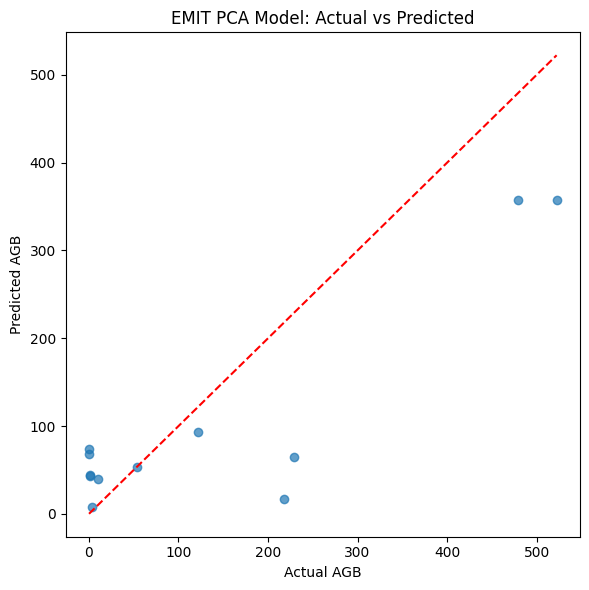

In [25]:
# EMIT Prediction Plot

import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.7)

# Perfect prediction line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual AGB")
plt.ylabel("Predicted AGB")
plt.title("EMIT PCA Model: Actual vs Predicted")

plt.tight_layout()

The EMIT PCA model demonstrates a strong overall relationship between predicted and actual AGB values, as evidenced by the clear alignment of points along the diagonal. However, the model exhibits a systematic bias, overpredicting low biomass plots and underpredicting high biomass plots. This pattern reflects regression toward the mean, which is expected given the small sample size and the use of log-transformed targets. While the model captures general trends effectively, it struggles to fully represent extreme values, suggesting that additional data or structural features may be needed to improve performance at the tails of the distribution.

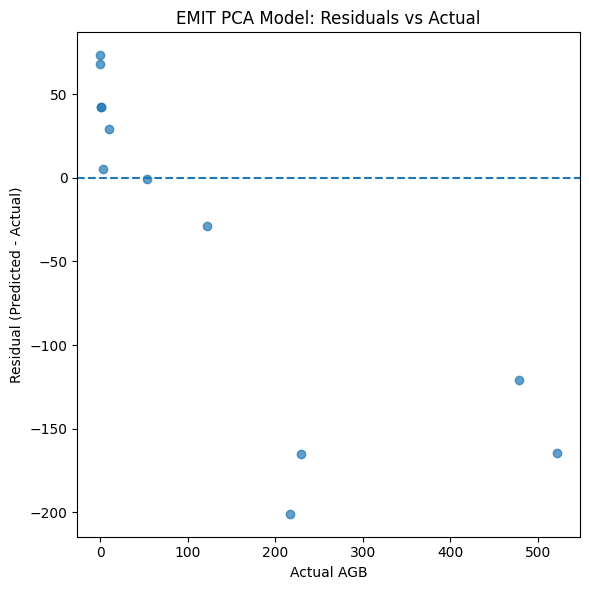

In [26]:
# Compute residuals

residuals = y_pred - y_true

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_true, residuals, alpha=0.7)

# Horizontal zero line
plt.axhline(0, linestyle='--')

plt.xlabel("Actual AGB")
plt.ylabel("Residual (Predicted - Actual)")
plt.title("EMIT PCA Model: Residuals vs Actual")

plt.tight_layout()

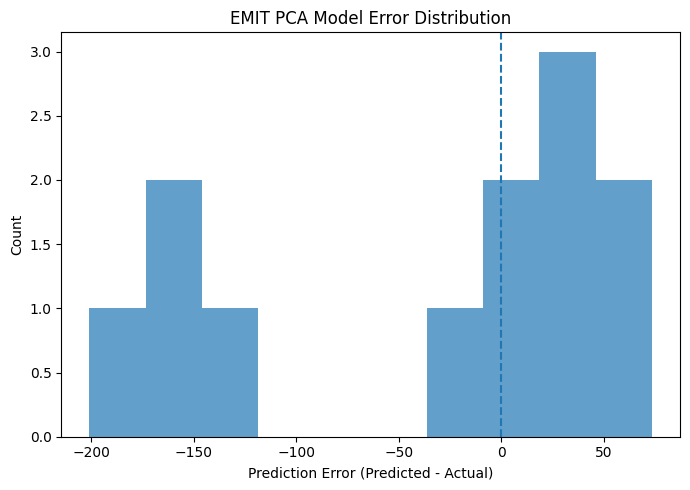

In [29]:
# Compute errors
emit_errors = y_pred - y_true

# sentinel_errors = y_pred_sentinel - y_true


plt.figure(figsize=(7,5))

plt.hist(emit_errors, bins=10, alpha=0.7)

plt.axvline(0, linestyle='--')

plt.xlabel("Prediction Error (Predicted - Actual)")
plt.ylabel("Count")
plt.title("EMIT PCA Model Error Distribution")

plt.tight_layout()

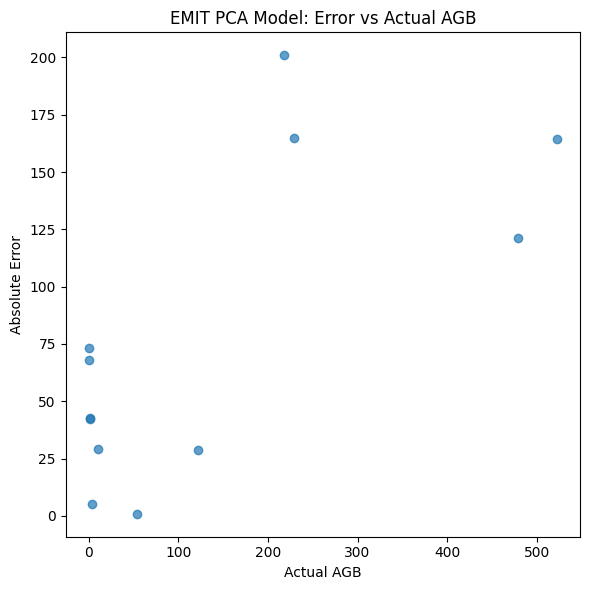

In [30]:
# Absolute error
abs_error = np.abs(y_pred - y_true)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_true, abs_error, alpha=0.7)

plt.xlabel("Actual AGB")
plt.ylabel("Absolute Error")
plt.title("EMIT PCA Model: Error vs Actual AGB")

plt.tight_layout()

The relationship between absolute prediction error and actual AGB reveals a clear upward trend, indicating that model error increases with biomass. While the EMIT PCA model performs well for low to moderate biomass values, it becomes progressively less accurate for higher biomass plots. This pattern is consistent with earlier residual and error distribution analyses and suggests that, despite the richness of hyperspectral EMIT data, distinguishing very high biomass levels remains challenging. This may be due to spectral saturation effects, limited representation of high biomass samples, and the use of log-transformed targets, all of which contribute to reduced sensitivity at the upper end of the distribution.

Diffusion on EMIT

In [31]:
# Use PCA features already created

X_train_c = X_train_pca
X_test_c  = X_test_pca
X_train_c = np.hstack([X_train_c, train_plot[["latitude", "longitude"]].values])
X_test_c  = np.hstack([X_test_c, test_plot[["latitude", "longitude"]].values])

print("Condition shape:", X_train_c.shape)

Condition shape: (47, 7)


In [32]:
# Standardizing target

y_mean = y_train.mean()
y_std  = y_train.std()

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled  = (y_test - y_mean) / y_std

print("Mean:", y_train_scaled.mean())
print("Std:", y_train_scaled.std())

Mean: -2.7637466783221984e-16
Std: 1.0


In [33]:
T = 30

betas = np.linspace(0.0001, 0.02, T)
alphas = 1 - betas
alpha_bars = np.cumprod(alphas)

print("T:", T)

T: 30


In [34]:
# Expanding dataset across timesteps


X_expanded = []
y_t_expanded = []
t_expanded = []
noise_expanded = []

for i in range(len(X_train_c)):
    for t in range(T):
        noise = np.random.normal(0, 1)

        y0 = y_train_scaled[i]

        y_t = (
            np.sqrt(alpha_bars[t]) * y0 +
            np.sqrt(1 - alpha_bars[t]) * noise
        )

        X_expanded.append(X_train_c[i])
        y_t_expanded.append(y_t)
        t_expanded.append(t / T)
        noise_expanded.append(noise)

X_expanded = np.array(X_expanded)
y_t_expanded = np.array(y_t_expanded).reshape(-1, 1)
t_expanded = np.array(t_expanded).reshape(-1, 1)
noise_expanded = np.array(noise_expanded).reshape(-1, 1)

print("Expanded X:", X_expanded.shape)

Expanded X: (1410, 7)


In [35]:
# Builidng Diffusion Model

from tensorflow.keras import layers, Model

x_input = layers.Input(shape=(X_expanded.shape[1],))
y_input = layers.Input(shape=(1,))
t_input = layers.Input(shape=(1,))

combined = layers.Concatenate()([x_input, y_input, t_input])

h = layers.Dense(64, activation="relu")(combined)
h = layers.Dense(64, activation="relu")(h)
h = layers.Dense(32, activation="relu")(h)

output = layers.Dense(1)(h)

diff_model = Model(inputs=[x_input, y_input, t_input], outputs=output)

diff_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

diff_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 9)         │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ input_layer_3[0]… │
│                     │                   │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │        640 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      4,160 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      2,080 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         33 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,913 (27.00 KB)

 Trainable params: 6,913 (27.00 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = diff_model.fit(
    [X_expanded, y_t_expanded, t_expanded],
    noise_expanded,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 3.2196 - mae: 1.2613 - val_loss: 0.9759 - val_mae: 0.7970
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0335 - mae: 0.8106 - val_loss: 1.0280 - val_mae: 0.8172
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0344 - mae: 0.8122 - val_loss: 0.9579 - val_mae: 0.7906
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0305 - mae: 0.8110 - val_loss: 0.9521 - val_mae: 0.7901
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0392 - mae: 0.8167 - val_loss: 0.9517 - val_mae: 0.7903
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9703 - mae: 0.7872 - val_loss: 0.9522 - val_mae: 0.7895
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9367 - mae: 0.7689 - val_loss: 1.0076 - val_mae: 0.8071
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9733 - mae: 0.7866 - val_loss: 0.9752 - val_mae: 0.7982
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.96

In [37]:
# Sampling fuction for EMIT diffusion

def sample_emit_diffusion(model, X_condition, n_samples=100):
    all_samples = []

    for _ in range(n_samples):
        # Start from pure noise
        y_sample = np.random.normal(size=(X_condition.shape[0], 1))

        # Reverse diffusion
        for t in reversed(range(T)):
            t_scaled = np.full((X_condition.shape[0], 1), t / T)

            pred_noise = model.predict(
                [X_condition, y_sample, t_scaled],
                verbose=0
            )

            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            y_sample = (1 / np.sqrt(alpha_t)) * (
                y_sample - ((1 - alpha_t) / np.sqrt(1 - alpha_bar_t)) * pred_noise
            )

            if t > 0:
                z = np.random.normal(size=y_sample.shape)
                y_sample = y_sample + np.sqrt(beta_t) * z

        all_samples.append(y_sample.ravel())

    return np.array(all_samples)

In [38]:
samples_scaled = sample_emit_diffusion(
    diff_model,
    X_test_c,
    n_samples=100
)

print("Samples shape:", samples_scaled.shape)

Samples shape: (100, 12)


In [39]:
# Converting diffusion samples back to AGB and evaluate

# Convert standardized log samples back to log scale
samples_log = samples_scaled * y_std + y_mean

# Convert log AGB to real AGB
samples_agb = np.expm1(samples_log)

# Point prediction = mean of sampled predictions
diff_pred = samples_agb.mean(axis=0)

# Uncertainty intervals
diff_lower = np.percentile(samples_agb, 5, axis=0)
diff_upper = np.percentile(samples_agb, 95, axis=0)

# Actual test values
y_true = np.expm1(y_test)

# Metrics
rmse_diff = np.sqrt(mean_squared_error(y_true, diff_pred))
mae_diff = mean_absolute_error(y_true, diff_pred)
r2_diff = r2_score(y_true, diff_pred)

print("EMIT PCA Diffusion Results")
print("RMSE:", rmse_diff)
print("MAE:", mae_diff)
print("R2:", r2_diff)

print("\nUncertainty interval examples:")
for i in range(5):
    print(
        "Actual:", round(y_true[i], 2),
        "| Pred mean:", round(diff_pred[i], 2),
        "| 5-95% interval:",
        round(diff_lower[i], 2),
        "-",
        round(diff_upper[i], 2)
    )

EMIT PCA Diffusion Results
RMSE: 905.0237588888369
MAE: 759.4552535413013
R2: -23.833182190015904

Uncertainty interval examples:
Actual: 0.13 | Pred mean: 975.45 | 5-95% interval: 1.95 - 4235.25
Actual: 0.23 | Pred mean: 857.14 | 5-95% interval: 2.12 - 3734.23
Actual: 10.65 | Pred mean: 1165.08 | 5-95% interval: 2.03 - 4718.23
Actual: 479.11 | Pred mean: 664.49 | 5-95% interval: 3.19 - 3721.43
Actual: 522.33 | Pred mean: 603.75 | 5-95% interval: -0.26 - 2031.84


Applying diffusion modeling to the EMIT PCA features resulted in very poor performance, with an R² of approximately -23.8 and predictions collapsing toward large, unrealistic values. The model also produced extremely wide uncertainty intervals, indicating a failure to learn meaningful structure in the data. This contrasts sharply with the strong performance of the neural network model (R² ≈ 0.685) using the same EMIT features. The failure of diffusion in this setting is likely due to the small sample size and the increased complexity of the diffusion framework, which requires substantially more data to learn stable noise distributions. These results suggest that while diffusion can be useful for uncertainty estimation in larger datasets, it is not well-suited for small, structured regression problems such as this one.

Residual diffusion builds on your EMIT PCA neural network instead of replacing it. Since the NN already captures most of the signal (R² ≈ 0.685), diffusion is used only to model the remaining errors rather than the full AGB prediction. This makes the problem much simpler and more stable, especially with a small dataset. It’s worth pursuing because it combines strong baseline predictions with uncertainty estimation and small corrections, making diffusion more effective and appropriate in this setting.

In [40]:
# Computing residuals


y_pred_log_nn = emit_pca_model.predict(X_test_scaled).ravel()
y_train_pred_log_nn = emit_pca_model.predict(X_train_scaled).ravel()

residual_train = y_train - y_train_pred_log_nn
residual_test  = y_test - y_pred_log_nn

print("Residual train mean:", residual_train.mean())
print("Residual train std:", residual_train.std())
print("First 5 residuals:", residual_train[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 376ms/step
Residual train mean: 0.5087345728101753
Residual train std: 1.6286205201968862
First 5 residuals: [ 0.28908618  0.02305326 -1.42999085  2.41070917  1.65287091]


In [41]:
# Standardizing residuals

res_mean = residual_train.mean()
res_std  = residual_train.std()

res_train_scaled = (residual_train - res_mean) / res_std
res_test_scaled  = (residual_test - res_mean) / res_std

print("Scaled residual mean:", res_train_scaled.mean())
print("Scaled residual std:", res_train_scaled.std())

Scaled residual mean: 9.448706592554524e-17
Scaled residual std: 0.9999999999999999


In [42]:
X_train_c = X_train_final
X_test_c  = X_test_final

In [43]:
T = 30

betas = np.linspace(0.0001, 0.02, T)
alphas = 1 - betas
alpha_bars = np.cumprod(alphas)

X_expanded = []
y_t_expanded = []
t_expanded = []
noise_expanded = []

for i in range(len(X_train_c)):
    for t in range(T):
        noise = np.random.normal(0, 1)

        y0 = res_train_scaled[i]

        y_t = (
            np.sqrt(alpha_bars[t]) * y0 +
            np.sqrt(1 - alpha_bars[t]) * noise
        )

        X_expanded.append(X_train_c[i])
        y_t_expanded.append(y_t)
        t_expanded.append(t / T)
        noise_expanded.append(noise)

X_expanded = np.array(X_expanded)
y_t_expanded = np.array(y_t_expanded).reshape(-1, 1)
t_expanded = np.array(t_expanded).reshape(-1, 1)
noise_expanded = np.array(noise_expanded).reshape(-1, 1)

print("Expanded:", X_expanded.shape)

Expanded: (1410, 7)


In [44]:
# reuse same architecture

diff_model_res = Model(inputs=[x_input, y_input, t_input], outputs=output)

diff_model_res.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [45]:
history = diff_model_res.fit(
    [X_expanded, y_t_expanded, t_expanded],
    noise_expanded,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 1.1071 - mae: 0.8366 - val_loss: 0.9815 - val_mae: 0.7570
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0003 - mae: 0.7969 - val_loss: 1.0757 - val_mae: 0.8260
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0113 - mae: 0.7960 - val_loss: 1.1394 - val_mae: 0.8153
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9694 - mae: 0.7919 - val_loss: 0.9861 - val_mae: 0.7625
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9057 - mae: 0.7603 - val_loss: 1.1035 - val_mae: 0.8001
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8934 - mae: 0.7572 - val_loss: 1.0642 - val_mae: 0.8029
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9165 - mae: 0.7598 - val_loss: 1.1329 - val_mae: 0.8188
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8865 - mae: 0.7497 - val_loss: 1.7389 - val_mae: 1.0454
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.84

In [46]:
# Sampling residual diffusion

def sample_residual_diffusion(model, X_condition, n_samples=100):
    all_samples = []

    for _ in range(n_samples):
        y_sample = np.random.normal(size=(X_condition.shape[0], 1))

        for t in reversed(range(T)):
            t_scaled = np.full((X_condition.shape[0], 1), t / T)

            pred_noise = model.predict(
                [X_condition, y_sample, t_scaled],
                verbose=0
            )

            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            y_sample = (1 / np.sqrt(alpha_t)) * (
                y_sample - ((1 - alpha_t) / np.sqrt(1 - alpha_bar_t)) * pred_noise
            )

            if t > 0:
                z = np.random.normal(size=y_sample.shape)
                y_sample = y_sample + np.sqrt(beta_t) * z

        all_samples.append(y_sample.ravel())

    return np.array(all_samples)

In [47]:
res_samples_scaled = sample_residual_diffusion(
    diff_model_res,
    X_test_c,
    n_samples=100
)

print("Residual samples shape:", res_samples_scaled.shape)

Residual samples shape: (100, 12)


In [48]:
# Reconstructing hybrid predictions and evaluating

res_samples_log = res_samples_scaled * res_std + res_mean
hybrid_log_samples = y_pred_log_nn.reshape(1, -1) + res_samples_log
hybrid_agb_samples = np.expm1(hybrid_log_samples)

hybrid_pred = hybrid_agb_samples.mean(axis=0)
hybrid_lower = np.percentile(hybrid_agb_samples, 5, axis=0)
hybrid_upper = np.percentile(hybrid_agb_samples, 95, axis=0)

y_true = np.expm1(y_test)
rmse_hybrid = np.sqrt(mean_squared_error(y_true, hybrid_pred))
mae_hybrid = mean_absolute_error(y_true, hybrid_pred)
r2_hybrid = r2_score(y_true, hybrid_pred)

print("EMIT PCA NN + Residual Diffusion Results")
print("RMSE:", rmse_hybrid)
print("MAE:", mae_hybrid)
print("R2:", r2_hybrid)

print("\nExamples:")
for i in range(5):
    print(
        "Actual:", round(y_true[i], 2),
        "| NN:", round(np.expm1(y_pred_log_nn[i]), 2),
        "| Hybrid:", round(hybrid_pred[i], 2),
        "| 5-95%:",
        round(hybrid_lower[i], 2),
        "-",
        round(hybrid_upper[i], 2)
    )

EMIT PCA NN + Residual Diffusion Results
RMSE: 735.749667361848
MAE: 489.18488859477657
R2: -15.412417744553167

Examples:
Actual: 0.13 | NN: 68.08 | Hybrid: 378.16 | 5-95%: 5.31 - 1576.8
Actual: 0.23 | NN: 73.63 | Hybrid: 296.43 | 5-95%: 11.08 - 1370.11
Actual: 10.65 | NN: 39.67 | Hybrid: 231.0 | 5-95%: 5.36 - 733.89
Actual: 479.11 | NN: 357.92 | Hybrid: 2261.13 | 5-95%: 28.6 - 8648.46
Actual: 522.33 | NN: 357.74 | Hybrid: 2119.23 | 5-95%: 36.05 - 10353.25


Residual diffusion was explored as a refinement to the EMIT PCA neural network by modeling prediction errors instead of the full target. However, this approach also performed poorly, resulting in a negative R² and unstable predictions. This suggests that, given the small dataset and the strong performance of the baseline neural network, there is limited structured residual signal for diffusion to learn. Instead of improving predictions, the diffusion model introduced additional noise, leading to degraded performance and overly wide uncertainty intervals.